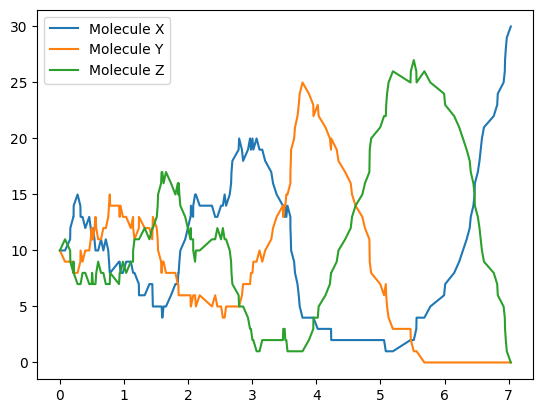

In [15]:
# import some helpful libraries
import numpy as np
from scipy.special import comb
import matplotlib.pyplot as plt

# initialize simulation states
# species: X, Y, Z

# reactions: X+Y->2Y, Y+Z->2Z, X+Z->2X
# note that this is a non-poset game (more specifically a cyclic game)
molecule_counts = np.array([10, 10, 10])

reactant_matrix = np.array([[1,1,0],
                            [0,1,1],
                            [1,0,1]])
product_matrix  = np.array([[0,2,0],
                            [0,0,2],
                            [2,0,0]])
stochastic_rate_constants = np.array([0.1,0.1,0.1])

time_max = 30
current_time = 0

# setup some variables to hold simulation snapshots:
snapshot_times = []
snapshot_molecules = []

# set up a random number generator we will use:
rng = np.random.default_rng(seed=42)

# check that the shapes of simulation parameters are consistent
assert (molecule_counts.shape[0] == reactant_matrix.shape[1]) and (molecule_counts.shape[0] == product_matrix.shape[1]),"Inconsistent number of species"

assert (stochastic_rate_constants.shape[0] == reactant_matrix.shape[0]) and (stochastic_rate_constants.shape[0] == product_matrix.shape[0]), "Inconsistent number of elementary reaction channels"

# add first state to snapshots:
snapshot_times.append(current_time)
snapshot_molecules.append(molecule_counts.copy())

while True:
  # compute reactant combinations:
  per_rc_combinations = np.prod(comb(molecule_counts, reactant_matrix, exact=False), axis=1)
  # Compute RC propensities
  propensities = per_rc_combinations * stochastic_rate_constants

  total_propensity = propensities.sum()

  # check if simulation should be stopped
  if current_time >= time_max or total_propensity == 0:
    break
  
  # sample a waiting time tau:
  # note that in numpy, we need 1/total_propensity since it asks for the scale parameter (not the rate)
  tau = rng.exponential(scale=1/total_propensity)
  current_time += tau

  # sample a reaction to occur:
  reaction_probabilities = propensities / total_propensity
  reaction_idx = rng.choice(reactant_matrix.shape[0], p=reaction_probabilities)

  # update molecule counts:
  molecule_counts -= reactant_matrix[reaction_idx]
  molecule_counts += product_matrix[reaction_idx]

  snapshot_times.append(current_time)
  snapshot_molecules.append(molecule_counts.copy())

snapshot_molecules = np.array(snapshot_molecules)

molecule_names = ["X","Y","Z"]

for mol_idx in range(molecule_counts.shape[0]):
  plt.plot(snapshot_times, snapshot_molecules[:, mol_idx], label=f"Molecule {molecule_names[mol_idx]}")

plt.legend()
plt.savefig("reaction_trajectory.png")
plt.show()